In [ ]:
#!pip install squarenet

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from squarenet import SquareNet
from squarenet.sampler import samplepoints
from squarenet.utils import show_search_result

In [5]:
save_path = "sqrnet/plot" #for the plots

## ❒ SquareNet

Fitting our first dataset
-1 million points randomly sampled on the 2D map of France

In [15]:
I = 1_000
N = I*I
points = samplepoints("france", size = (N, 2))
sn = SquareNet(gridshape = (I, I))
sn.fit(points, method = "robust")

Starting gridification... available method [fast, robust, ultimate]
selected fast

=== Carthesian sort ===
(max iter: 1000)
[█████████████████████████████] 1000/1000

=== Final Status ===
succesfully sorted at iteration 22


Now France is grided

figure will be saved at sqrnet\plot.png


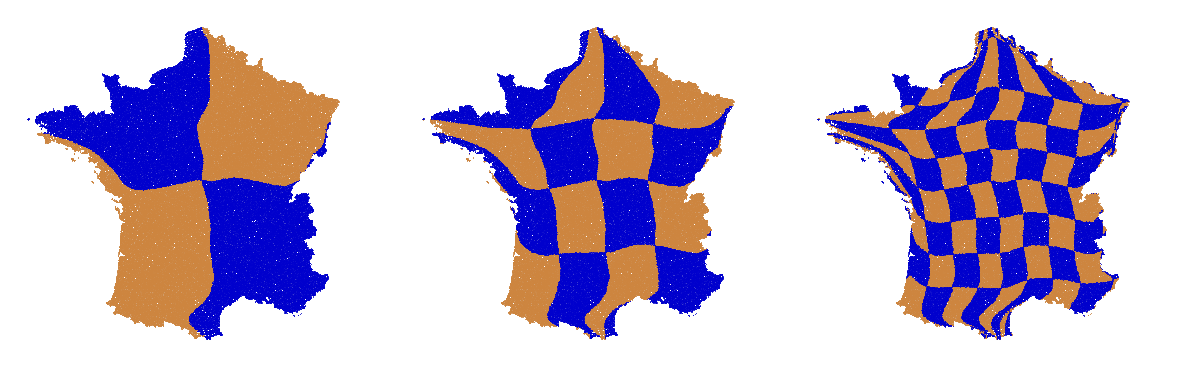

(<Figure size 1200x400 with 3 Axes>, None)

In [6]:
sn.plot(style = "checkerboard", save_path = save_path) #should look like a checkerboard pattern

## 📡 Search Sorted:

Squarenet allow for a powerfull D-dimensional version of the 1D search sorted 

random point x,y = (0.79, 0.18)


true index (np.int32(806), np.int32(110))
with search sorted: [806 109] [807 110]


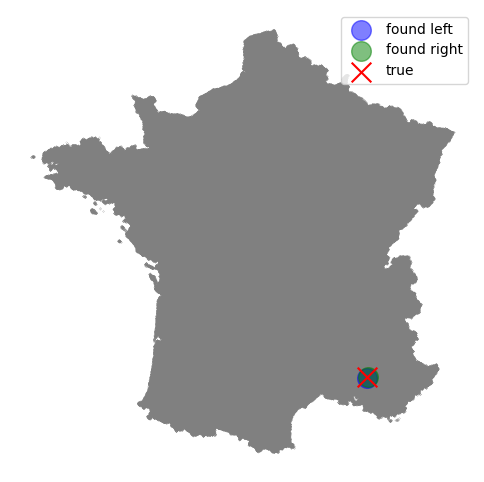

In [7]:
#(x, y) coordinates of a random point in France
true_index = np.random.choice(N)
grid_multi_index = sn.mapidx(true_index)
point = points[true_index] 

x, y = point[0], point[1]
print(f"random point x,y = ({x:.2f}, {y:.2f})\n\n")

#search sorted is a heuristic method that will find an
# (almost optimal) position in the grid that best 
# fit the spatial coordinates of an unseen point.
# Augment n_iter to get better accuracy

#/!\ search sorted is fast, but will not give the exact nearest neighbor.

left_multi_index = sn.search_sorted(point, n_iter = 4, side = "left") 
right_multi_index = sn.search_sorted(point, n_iter = 4, side = "right")

show_search_result(left_multi_index, right_multi_index, true_index, points, sn)

Fitting some holy dataset, again 1 million points in 2D

In [8]:
I = 1_000
N = I*I
points = samplepoints("holy", size = (N, 2))
sn = SquareNet(gridshape = (I, I))

sn.fit(points)

Starting gridification... available method [fast, robust, ultimate]
selected fast

=== Carthesian sort ===
(max iter: 1000)
[█████████████████████████████] 1000/1000

=== Final Status ===
succesfully sorted at iteration 18


figure will be saved at sqrnet\plot_1.png


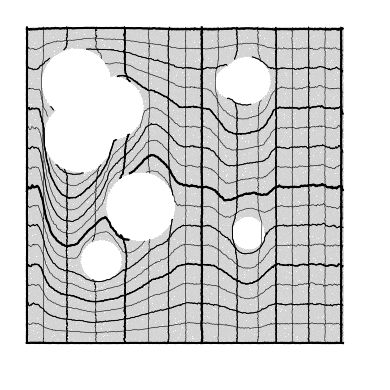

(<Figure size 400x400 with 1 Axes>, None)

In [9]:
sn.plot(style = "mesh", save_path = save_path)

## ⚛️ Neighbormap

Neighbormap provides a **fast diagnostic of grid quality** by estimating how close \
true nearest neighbors remain in **grid-index space**.

In the printed neighbormap, in each cell you will find how many points Y were the nearest neighbor \
of the central points X in that particular cell relative to X cell, accros 20 million evenly sampled pairs (X, Y).

If you need the matrix to compute something on it (instead of just a print) or to give a custom distance kernel etc:\
from squarenet.neighbormap import neighbormap \
-> more parameters and more control

In [11]:
sn.neighbormap(log2 = False)

neighbor map on axes (0, 1)
                                                                                                                                               1         1
                                                                                   1         1                                       1                    
             1    1                   1         1              1    1         1         1                                                                 
        1                   2    3    1    2    5    3    6   10   10   20   15   18   13    2    2    2    1    1         2         1    1               
                  2    2         4    8    7    5   12   33   51  161  343  401  343  166   42   29   18    9    7    5    3    2    3    3              1
                       1    3    8   13   12   30   45   85  250  798 2454 4343 2406  761  226   76   52   20    9    8    5    6    1    1              1
                                          

Fitting something spiky (1million points, 3D).

In [ ]:
I = 100
N = I*I*I
points = samplepoints("spiky", size = (N, 3))
sn = SquareNet(gridshape = (I, I, I))

sn.fit(points, method = "robust")

Starting gridification... available method [fast, robust]
selected robust

=== Carthesian sort ===
[█████████████████████████████] 100/100

=== Final Status ===
succesfully sorted at iteration 120


figure will be saved at sqrnet\plot.gif
ffmpeg unavailable. Npoints = 1000000 and style is 'scatter' -> could take 1/2 minutes


(<Figure size 400x400 with 1 Axes>,
 <matplotlib.animation.FuncAnimation at 0x1e7007a3050>)

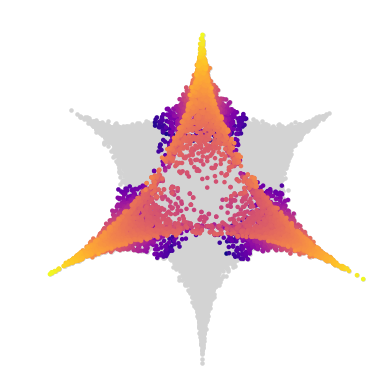

In [ ]:
sn.plot(animate = True, style = "scatter", save_path = save_path)

Fitting a Manifold (1million points, 2d latent loop in a 4D space). Just put 1 for some of the grid dimensions

In [ ]:
I = 1_000
N = I*I*1*1
points = samplepoints("4Dloop", size = (N, 4))
sn = SquareNet(gridshape = (I, I, 1, 1))

sn.fit(points)

Starting gridification... available method [fast, robust]
selected fast

=== Carthesian sort ===
[█████████████████████████████] 100/100

=== Final Status ===
succesfully sorted at iteration 30


figure will be saved at sqrnet\plot_1.gif
ffmpeg unavailable. Npoints = 1000000 and style is 'scatter' -> could take 1/2 minutes


(<Figure size 400x400 with 1 Axes>,
 <matplotlib.animation.FuncAnimation at 0x1e7007a3c50>)

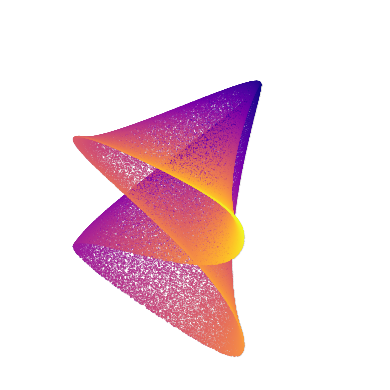

In [ ]:
sn.plot(style = "scatter", animate = True, save_path = save_path)

## ⏱ Practical trade-off

Exploring with fast, robust and ultimate method, you will find following empiricall caracteristics:


| Method   | Quality (NN locality) | Speed        | Stability        | Recommended use |
|----------|----------------------|--------------|------------------|------------------|
| fast     | medium               | very high    | axis-biased      | large-scale / preprocessing |
| robust   | high                 | high         | balanced         | default choice |
| ultimate* | very high            | low           | most stable      | offline high-quality grids |

⚠️ Ultimate method needs a suffisant (potentially very high) max iter parameter to give the best results.\
Max_iter is default to 1000 which is good in many cases for small/medium number of points, but for datasets \
with more than 1 Million points and a tricky geometry 10_000 iterations will be neaded to be safely \
considered as optimal, wich would lead to a 20 minutes long fit.

In [13]:
print(sn.max_iter)

1000


➡️ ![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)[  02. JAX and PyTorch](https://colab.research.google.com/github/ArmanddeCacqueray/SquareNet/blob/main/02_jax_and_pytorch.ipynb)